In [2]:
!pip install rasterio numpy matplotlib tensorflow scikit-learn tqdm

In [15]:
import os
import numpy as np
import rasterio
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import random

# Set seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 2


In [24]:
data_root = "/kaggle/input/trainingdataset/Merged5Classes"

# Define classes
class_names = ['Barren_Land', 'Built-up_Area', 'Crop', 'Forest', 'Water']
class_to_label = {name: i for i, name in enumerate(class_names)}

X = []
y = []
patch_labels = []

# Load 500 images per class
for class_name in class_names:
    class_path = os.path.join(data_root, class_name)
    tif_files = sorted([f for f in os.listdir(class_path) if f.endswith('.tif')])[:3000]

    for file in tqdm(tif_files, desc=f"Loading {class_name}"):
        file_path = os.path.join(class_path, file)
        with rasterio.open(file_path) as src:
            # Read required bands (13 bands total: B1..B12 + AOT)
            B1 = src.read(1).astype('float32')  # Coastal aerosol
            B2 = src.read(2).astype('float32')  # Blue
            B3 = src.read(3).astype('float32')  # Green
            B4 = src.read(4).astype('float32')  # Red
            B5 = src.read(5).astype('float32')  # Red Edge 1
            B6 = src.read(6).astype('float32')  # Red Edge 2
            B7 = src.read(7).astype('float32')  # Red Edge 3
            B8 = src.read(8).astype('float32')  # NIR
            B8A = src.read(9).astype('float32') # Narrow NIR
            B9 = src.read(10).astype('float32') # Water vapor
            SCL = src.read(11).astype('float32')
            B11 = src.read(12).astype('float32')# SWIR 1
            B12 = src.read(13).astype('float32')# SWIR 2

            # Indices
            NDVI = (B8 - B4) / (B8 + B4 + 1e-8)
            NDBI = (B11 - B8) / (B11 + B8 + 1e-8)
            NDWI = (B3 - B11) / (B3 + B11 + 1e-8)

            # Stack: NDVI, NDBI, NDWI, Bands (B1..B12)
            stacked = np.stack(
                [NDVI, NDBI, NDWI, B1, B2, B3, B4, B5, B6, B7, B8, B8A, B9, SCL, B11, B12],
                axis=-1
            )  # shape (H, W, 16)

            label = class_to_label[class_name]
            label_mask = np.full((stacked.shape[0], stacked.shape[1]), label)

            X.append(stacked)
            y.append(label_mask)
            patch_labels.append(label)

X = np.array(X)
y = np.array(y)
patch_labels = np.array(patch_labels)

print("Input shape:", X.shape)
print("Label shape:", y.shape)

Loading Water: 100%|██████████| 3000/3000 [00:25<00:00, 115.47it/s]


Input shape: (14030, 64, 64, 16)
Label shape: (14030, 64, 64)


In [25]:
# Train-test split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=patch_labels
)
print(f"Training samples: {len(X_train)}, Validation samples: {len(X_val)}")

# Model Structure 
def build_unet(input_shape=(64, 64, 16), num_classes=5):
    inputs = tf.keras.Input(shape=input_shape)  # 16 channels explicitly
    # Encoder
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D(2)(c1)
    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D(2)(c2)
    # Bottleneck
    b1 = layers.Conv2D(128, 3, activation='relu', padding='same')(p2)
    b1 = layers.Conv2D(128, 3, activation='relu', padding='same')(b1)
    # Decoder
    u1 = layers.UpSampling2D(2)(b1)
    u1 = layers.concatenate([u1, c2])
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(u1)
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(c3)
    u2 = layers.UpSampling2D(2)(c3)
    u2 = layers.concatenate([u2, c1])
    c4 = layers.Conv2D(32, 3, activation='relu', padding='same')(u2)
    c4 = layers.Conv2D(32, 3, activation='relu', padding='same')(c4)
    outputs = layers.Conv2D(num_classes, 1, activation='softmax')(c4)
    return models.Model(inputs, outputs)

Training samples: 12627, Validation samples: 1403


In [30]:
# Clear previous models
tf.keras.backend.clear_session()
model = build_unet(input_shape=X_train.shape[1:], num_classes=5)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

# Train
model.fit(X_train, y_train, epochs=30, batch_size=8, validation_data=(X_val, y_val))

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64,    │          0 │ -                 │
│ (InputLayer)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │      4,640 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 192)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    110,656 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │     36,928 │ conv2d_6[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 64, 64,    │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 64, 64,    │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 96)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │     27,680 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 64,    │      9,248 │ conv2d_8[0][0]  

 Total params: 475,429 (1.81 MB)

 Trainable params: 475,429 (1.81 MB)

 Non-trainable params: 0 (0.00 B)

...

1578/1579 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4337 - loss: 5.4931

W0000 00:00:1760016847.839703     112 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


1579/1579 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4337 - loss: 5.4908

W0000 00:00:1760016850.910538     110 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1760016851.998355     111 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


1579/1579 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - accuracy: 0.4338 - loss: 5.4884 - val_accuracy: 0.7326 - val_loss: 0.7362
Epoch 2/30
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.7153 - loss: 0.7698 - val_accuracy: 0.7707 - val_loss: 0.6263
Epoch 3/30
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.7956 - loss: 0.5962 - val_accuracy: 0.8088 - val_loss: 0.5344
Epoch 4/30
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8158 - loss: 0.5482 - val_accuracy: 0.8439 - val_loss: 0.4632
Epoch 5/30
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8347 - loss: 0.5128 - val_accuracy: 0.8499 - val_loss: 0.4463
Epoch 6/30
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.8400 - loss: 0.4982 - val_accuracy: 0.8666 - val_loss: 0.4083
Epoch 7/30
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.8546 - loss: 0.4493 - val_accuracy: 0.8632 - val_loss: 0.4268
Epoch 8/30
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8614 - loss: 0.4413

176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Classification Report:
               precision    recall  f1-score   support

  Barren_Land     0.8430    0.9059    0.8733    831488
Built-up_Area     0.9332    0.8929    0.9126   1228800
         Crop     0.9353    0.9542    0.9447   1228800
       Forest     0.9555    0.9684    0.9619   1228800
        Water     0.9623    0.9227    0.9421   1228800

     accuracy                         0.9304   5746688
    macro avg     0.9258    0.9288    0.9269   5746688
 weighted avg     0.9316    0.9304    0.9306   5746688



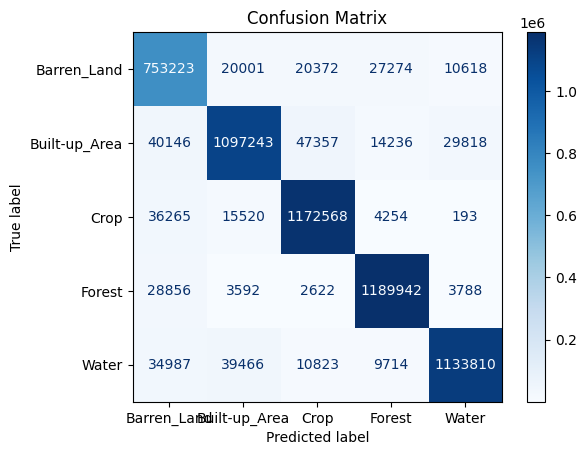


Overall Accuracy: 0.9304
Validation Loss: 0.2678
Validation Accuracy: 0.9304


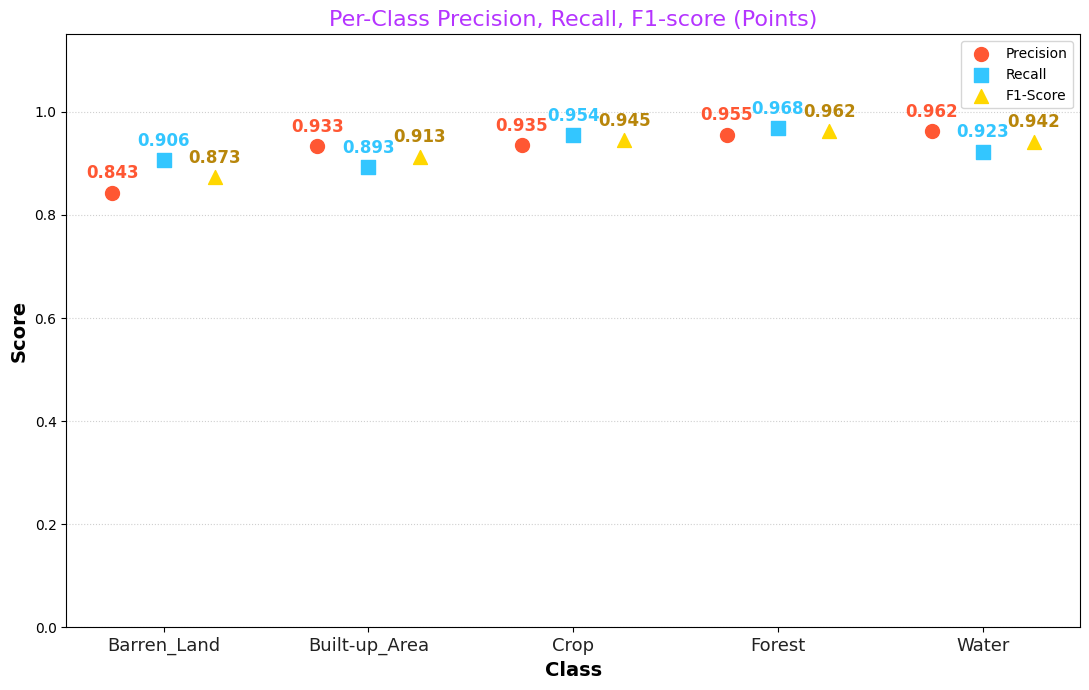

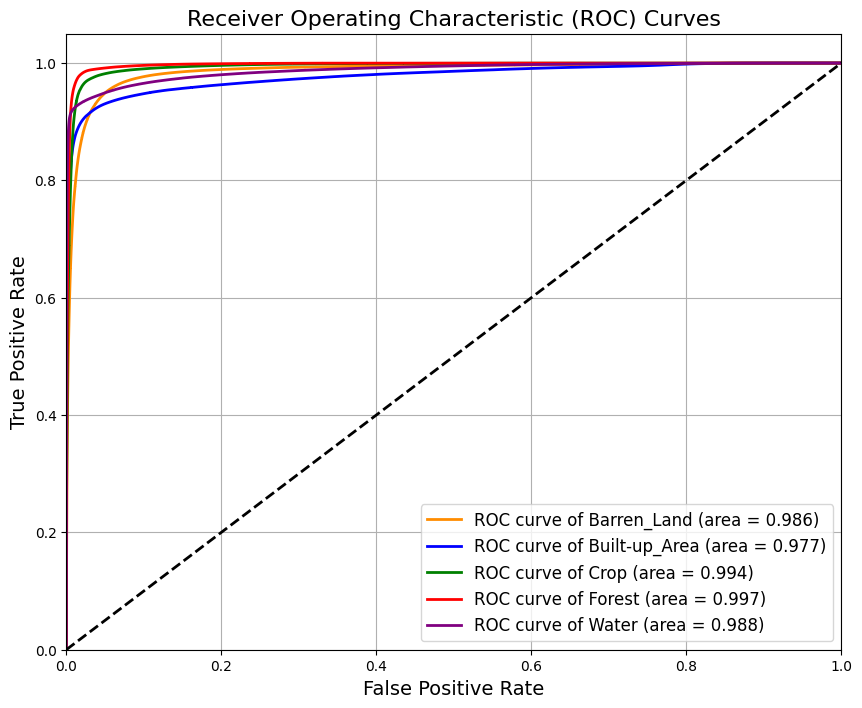

In [31]:
# Predict
y_pred_probs = model.predict(X_val, batch_size=8)
y_pred_classes = np.argmax(y_pred_probs, axis=-1).flatten()
y_true_classes = y_val.flatten()

# Metrics
print("Classification Report:")
print(classification_report(
    y_true_classes,
    y_pred_classes,
    target_names=['Barren_Land', 'Built-up_Area', 'Crop', 'Forest', 'Water'],
    digits=4
))

# Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Barren_Land', 'Built-up_Area', 'Crop', 'Forest', 'Water'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

# Accuracy
accuracy = np.mean(y_pred_classes == y_true_classes)
print(f"\nOverall Accuracy: {accuracy:.4f}")

# Evaluate
val_metrics = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Loss: {val_metrics[0]:.4f}")
if len(val_metrics) > 1:
    print(f"Validation Accuracy: {val_metrics[1]:.4f}")

# Compute metrics as dict
report = classification_report(
    y_true_classes,
    y_pred_classes,
    target_names=['Barren_Land', 'Built-up_Area', 'Crop', 'Forest', 'Water'],
    digits=4,
    output_dict=True
)

labels = ['Barren_Land', 'Built-up_Area', 'Crop', 'Forest', 'Water']
precision = [report[cls]['precision'] for cls in labels]
recall    = [report[cls]['recall']    for cls in labels]
f1        = [report[cls]['f1-score']  for cls in labels]

bar_width = 0.25
x = np.arange(len(labels))

plt.figure(figsize=(11,7))

# Plot points for each metric
plt.scatter(x - bar_width, precision, color='#FF5733', label='Precision', s=100, marker='o')
plt.scatter(x, recall, color='#33C6FF', label='Recall', s=100, marker='s')
plt.scatter(x + bar_width, f1, color='#FFD700', label='F1-Score', s=100, marker='^')

# Annotate points with values
for i in range(len(labels)):
    plt.text(x[i] - bar_width, precision[i] + 0.02, f"{precision[i]:.3f}", ha='center', va='bottom', fontsize=12, color='#FF5733', fontweight='bold')
    plt.text(x[i], recall[i] + 0.02, f"{recall[i]:.3f}", ha='center', va='bottom', fontsize=12, color='#33C6FF', fontweight='bold')
    plt.text(x[i] + bar_width, f1[i] + 0.02, f"{f1[i]:.3f}", ha='center', va='bottom', fontsize=12, color='#B8860B', fontweight='bold')

plt.xlabel('Class', fontsize=14, fontweight='bold')
plt.ylabel('Score', fontsize=14, fontweight='bold')
plt.title('Per-Class Precision, Recall, F1-score (Points)', fontsize=16, color='#B534FF')
plt.xticks(x, labels, fontsize=13, color='#222')
plt.ylim(0, 1.15)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Binarize the output labels for multi-class ROC
y_true_bin = label_binarize(y_true_classes, classes=[0,1,2,3,4])
y_score = y_pred_probs.reshape(-1, 5)  # predicted probabilities, shape (num_samples, 5)

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = 5
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
plt.figure(figsize=(10, 8))
colors = ['darkorange', 'blue', 'green', 'red', 'purple']
class_names = ['Barren_Land', 'Built-up_Area', 'Crop', 'Forest', 'Water']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {class_names[i]} (area = {roc_auc[i]:0.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # diagonal line for random guess
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Receiver Operating Characteristic (ROC) Curves', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True)
plt.show()

In [32]:
def clean_band(band):
    return np.nan_to_num(band, nan=0.0, posinf=0.0, neginf=0.0)

def preprocess_full_tif(tif_path):
    with rasterio.open(tif_path) as src:
        B1 = src.read(1).astype('float32')  # Coastal aerosol
        B2 = src.read(2).astype('float32')  # Blue
        B3 = src.read(3).astype('float32')  # Green
        B4 = src.read(4).astype('float32')  # Red
        B5 = src.read(5).astype('float32')  # Red Edge 1
        B6 = src.read(6).astype('float32')  # Red Edge 2
        B7 = src.read(7).astype('float32')  # Red Edge 3
        B8 = src.read(8).astype('float32')  # NIR
        B8A = src.read(9).astype('float32') # Narrow NIR
        B9 = src.read(10).astype('float32') # Water vapor
        SCL = src.read(11).astype('float32')
        B11 = src.read(12).astype('float32')# SWIR 1
        B12 = src.read(13).astype('float32')# SWIR 2

        B3 = clean_band(B3)
        B4 = clean_band(B4)
        B8 = clean_band(B8)
        B11 = clean_band(B11)

        valid_mask = (
            (B3 > 1) & (B4 > 1) & (B8 > 1) & (B11 > 1)
        )

        NDVI = (B8 - B4) / (B8 + B4 + 1e-8)
        NDBI = (B11 - B8) / (B11 + B8 + 1e-8)
        NDWI = (B3 - B11) / (B3 + B11 + 1e-8)

        stacked = np.stack([NDVI, NDBI, NDWI, B1, B2, B3, B4, B5, B6, B7, B8, B8A, B9, SCL, B11, B12], axis=-1)
        return stacked, valid_mask

def sliding_window_prediction(image, model, patch_size=64, stride=32):
    H, W, C = image.shape
    out_mask = np.zeros((H, W, model.output_shape[-1]))
    count_mask = np.zeros((H, W, 1))

    for row in range(0, H - patch_size + 1, stride):
        for col in range(0, W - patch_size + 1, stride):
            patch = image[row:row+patch_size, col:col+patch_size, :]
            patch_input = np.expand_dims(patch, axis=0)
            pred_patch = model.predict(patch_input)[0]
            out_mask[row:row+patch_size, col:col+patch_size, :] += pred_patch
            count_mask[row:row+patch_size, col:col+patch_size, :] += 1

    count_mask[count_mask == 0] = 1
    out_mask = out_mask / count_mask
    predicted = np.argmax(out_mask, axis=-1)
    confidence = np.max(out_mask, axis=-1)
    return predicted, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━

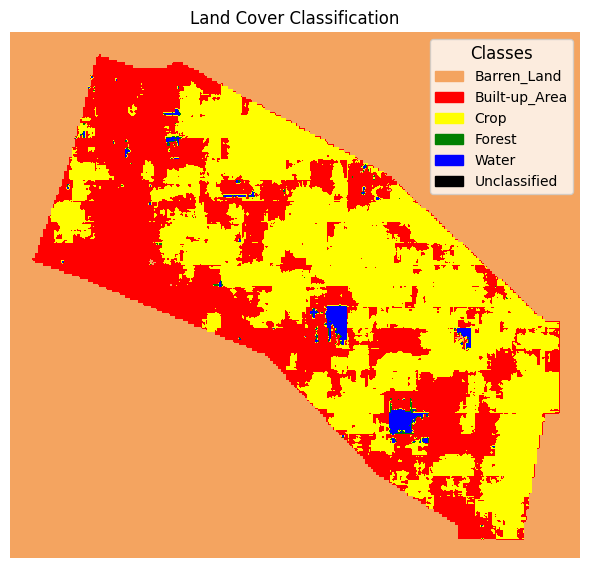

In [33]:
test_image_path = "/kaggle/input/s2-test/S2_2023_13_bands.tif"
image, _ = preprocess_full_tif(test_image_path)
predicted_mask, confidence = sliding_window_prediction(image, model)
nodata_value = 0  # use correct nodata value if it's different
valid_mask = np.any(image != nodata_value, axis=-1)  # valid area where any input band is not nodata
predicted_mask[~valid_mask] = 5  # 5 is the index for 'Unclassified' (black)

class_names = ['Barren_Land', 'Built-up_Area', 'Crop', 'Forest', 'Water', 'Unclassified']
colors = ["sandybrown", "red", "yellow", "green", "blue", "black"]
cmap = mcolors.ListedColormap(colors)
bounds = np.arange(len(class_names) + 1) - 0.5
norm = mcolors.BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(6,6))
plt.imshow(predicted_mask, cmap=cmap, norm=norm)
plt.axis('off')
plt.title("Land Cover Classification")

patches = [mpatches.Patch(color=colors[i], label=class_names[i]) for i in range(len(class_names))]
plt.legend(handles=patches, loc='upper right', title="Classes", fontsize=10, title_fontsize=12)
plt.tight_layout()
plt.show()

In [34]:
model.save('landcover_unet_model.h5')
print("Model saved successfully.")

Model saved successfully.
